<a href="https://colab.research.google.com/github/sYanXO/LLM-inferencing/blob/main/Copy_of_phi_3_1_mini_tinkering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu122

Looking in indexes: https://pypi.org/simple, https://abetlen.github.io/llama-cpp-python/whl/cu122
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 GB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.0 MB/s eta 0:00:00


In [ ]:
# Create a dedicated models folder in the root directory
!mkdir -p /content/models

# Download the Q2, Q4, and Q8 weights
!hf download bartowski/Phi-3.1-mini-4k-instruct-GGUF Phi-3.1-mini-4k-instruct-Q2_K.gguf --local-dir /content/models
!hf download bartowski/Phi-3.1-mini-4k-instruct-GGUF Phi-3.1-mini-4k-instruct-Q4_K_M.gguf --local-dir /content/models
!hf download bartowski/Phi-3.1-mini-4k-instruct-GGUF Phi-3.1-mini-4k-instruct-Q8_0.gguf --local-dir /content/models

Phi-3.1-mini-4k-instruct-Q2_K.gguf: 100% 1.42G/1.42G [00:10<00:00, 136MB/s]
✓ Downloaded
  path: /content/models/Phi-3.1-mini-4k-instruct-Q2_K.gguf
✓ Downloaded
  path: /content/models/Phi-3.1-mini-4k-instruct-Q4_K_M.gguf
✓ Downloaded
  path: /content/models/Phi-3.1-mini-4k-instruct-Q8_0.gguf


In [ ]:
from llama_cpp import Llama

# Swap this string to test the Q4_K_M and Q8_0 models next!
model_file = "Phi-3.1-mini-4k-instruct-Q8_0.gguf"

print(f"Loading {model_file} into VRAM...")
llm = Llama(
    model_path=f"/content/models/{model_file}", # Updated to absolute path
    n_gpu_layers=-1,
    n_ctx=1024,
    verbose=True
)

prompt = "Analyze the memory bandwidth constraints of a T4 GPU. " * 60

print("\n--- Starting Benchmark ---")
output = llm(
    prompt,
    max_tokens=128,
)

print("\nBenchmark complete! Look at the stderr logs above.")


ggml_cuda_init: found 1 CUDA devices (Total VRAM: 14912 MiB):
  Device 0: Tesla T4, compute capability 7.5, VMM: yes, VRAM: 14912 MiB


Loading Phi-3.1-mini-4k-instruct-Q8_0.gguf into VRAM...


llama_model_load_from_file_impl: using device CUDA0 (Tesla T4) (0000:00:04.0) - 14807 MiB free
llama_model_loader: loaded meta data with 39 key-value pairs and 195 tensors from /content/models/Phi-3.1-mini-4k-instruct-Q8_0.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = phi3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Phi 3 Mini 4k Instruct
llama_model_loader: - kv   3:                           general.finetune str              = 4k-instruct
llama_model_loader: - kv   4:                           general.basename str              = Phi-3
llama_model_loader: - kv   5:                         general.size_label str              = mini
llama_model_loader: - kv   6:         


--- Starting Benchmark ---


llama_perf_context_print:        load time =     811.27 ms
llama_perf_context_print: prompt eval time =     806.21 ms /   841 tokens (    0.96 ms per token,  1043.16 tokens per second)
llama_perf_context_print:        eval time =    2917.26 ms /   127 runs   (   22.97 ms per token,    43.53 tokens per second)
llama_perf_context_print:       total time =    3765.46 ms /   968 tokens
llama_perf_context_print:    graphs reused =        126



Benchmark complete! Look at the stderr logs above.


# LLM Inference Optimization: Memory vs. Compute Constraints on NVIDIA T4

## Objective
To analyze the architectural bottlenecks of Large Language Model (LLM) inference by benchmarking different GGUF quantizations of a 3.8B parameter model. The experiment maps the specific trade-offs between VRAM memory bandwidth (Token Generation) and CUDA core compute saturation (Prompt Processing).

## Hardware & Environment
* **Platform:** Google Colab (Free Tier)
* **GPU:** NVIDIA T4 Tensor Core GPU
* **Architecture:** Turing (Compute Capability 7.5)
* **VRAM:** 16GB GDDR6 (~320 GB/s Memory Bandwidth)
* **Engine:** `llama-cpp-python` (Compiled with `cu122` / `GGML_CUDA=ON`)

## Methodology
* **Model:** `Phi-3.1-mini-4k-instruct` (3.8B Parameters)
* **Quantizations Tested:** `Q2_K`, `Q4_K_M`, `Q8_0`
* **Prompt Processing (PP) Load:** ~841 tokens to stress parallel compute.
* **Token Generation (TG) Load:** 127 tokens to stress sequential memory bandwidth.
* **Context:** All layers offloaded to GPU VRAM (`n_gpu_layers=-1`).

## Benchmark Results

| Model Quantization | Prompt Processing (Compute) | Token Generation (Memory) |
| :--- | :--- | :--- |
| **Q2_K** (Highest Compression) | ~606 tokens/sec | ~52 tokens/sec |
| **Q4_K_M** (Medium Compression) | ~977 tokens/sec | **~55 tokens/sec** |
| **Q8_0** (Lowest Compression) | **~1043 tokens/sec** | ~43.5 tokens/sec |



## Architectural Takeaways

### 1. The Token Generation Bottleneck (Memory-Bound)
Token generation requires moving the entire model's weight matrix from the VRAM across the bus to the CUDA cores for *every single token generated*. The results clearly show this memory bandwidth limitation. The `Q8_0` model is roughly twice the physical file size of the `Q4_K_M` model. Consequently, its generation speed tanked to 43.5 t/s because it choked the T4's 320 GB/s memory bus, whereas lighter models moved across the bus much faster.

### 2. The Prompt Processing Advantage (Compute-Bound)
Unlike token generation, prompt processing computes the attention matrix for all prompt tokens in parallel. This phase is constrained by raw FLOPs rather than memory speed. The `Q8_0` model dominated this phase (1043 t/s) because 8-bit integers require almost zero complex unpacking logic, allowing the CUDA cores to ingest the bytes directly into matrix multiplications without delay.

### 3. The Dequantization "Sweet Spot"
Counter-intuitively, the `Q4_K_M` generated tokens faster than the highly compressed `Q2_K`. While the `Q2_K` takes up less VRAM bandwidth, it requires highly complex, irregular bit-shifting logic to dequantize back into FP16 inside the hardware registers. The `Q4_K_M` bit-packing aligns perfectly with standard hardware registers, meaning the GPU unpacks it so efficiently that it overcomes the minor increase in memory transfer time, making it the most optimized format for this hardware.

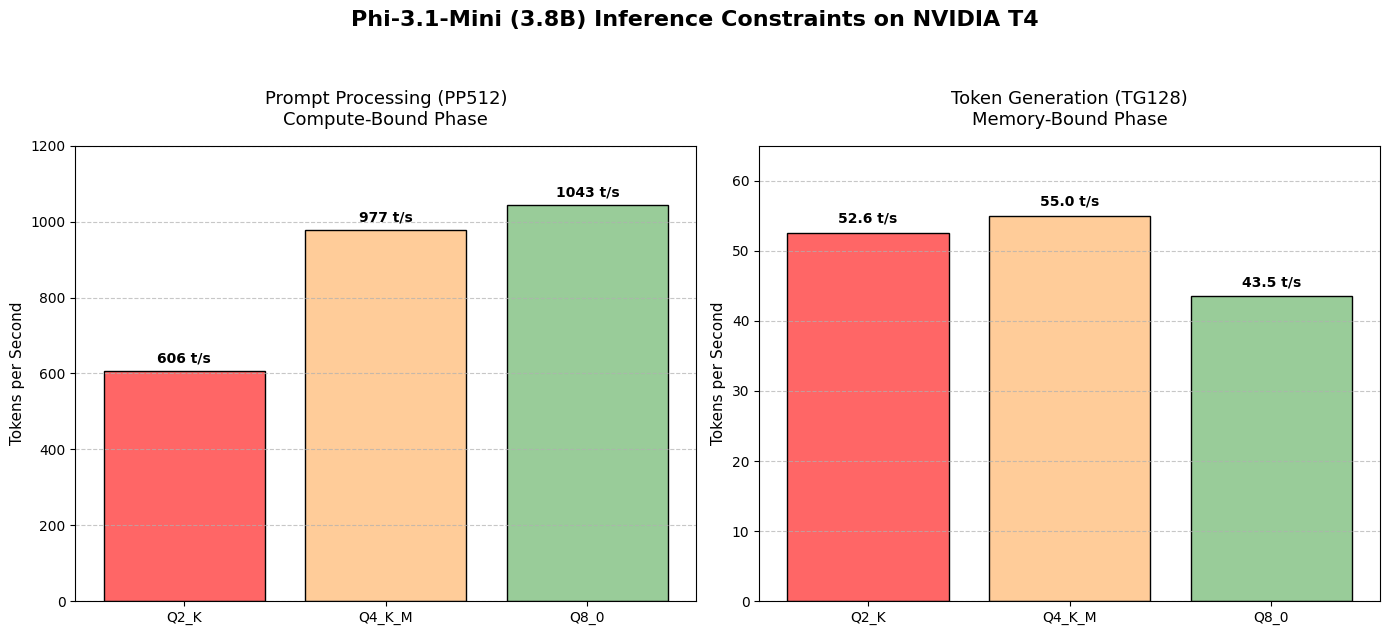


Chart saved successfully as 'inference_benchmark_results.png' in your Colab files!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Our benchmark data
models = ['Q2_K', 'Q4_K_M', 'Q8_0']
pp_speeds = [606, 977, 1043]
tg_speeds = [52.6, 55.0, 43.5]

# Set up the matplotlib figure with 2 side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Phi-3.1-Mini (3.8B) Inference Constraints on NVIDIA T4', fontsize=16, fontweight='bold', y=1.05)

# Colors to map the models consistently across both charts
colors = ['#ff6666', '#ffcc99', '#99cc99']

# --- Plot 1: Prompt Processing (Compute-Bound) ---
bars1 = ax1.bar(models, pp_speeds, color=colors, edgecolor='black')
ax1.set_title('Prompt Processing (PP512)\nCompute-Bound Phase', fontsize=13, pad=15)
ax1.set_ylabel('Tokens per Second', fontsize=11)
ax1.set_ylim(0, 1200)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add the exact numbers on top of the bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 15, f'{yval} t/s', ha='center', va='bottom', fontweight='bold')

# --- Plot 2: Token Generation (Memory-Bound) ---
bars2 = ax2.bar(models, tg_speeds, color=colors, edgecolor='black')
ax2.set_title('Token Generation (TG128)\nMemory-Bound Phase', fontsize=13, pad=15)
ax2.set_ylabel('Tokens per Second', fontsize=11)
ax2.set_ylim(0, 65)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval} t/s', ha='center', va='bottom', fontweight='bold')

# Polish the layout
plt.tight_layout()

# Save the high-res image for your GitHub markdown
plt.savefig('inference_benchmark_results.png', dpi=300, bbox_inches='tight')

# Display the chart in Colab
plt.show()

print("\nChart saved successfully as 'inference_benchmark_results.png' in your Colab files!")